# 선분의 내분 · 외분

두 점 $A(x_1,y_1)$, $B(x_2,y_2)$에 대해

**내분** ($m:n$으로 내분하는 점 $P$)

$$
P = \left( \frac{mx_2 + nx_1}{m+n},\; \frac{my_2 + ny_1}{m+n} \right)
$$

**외분** ($m:n$으로 외분하는 점 $Q$)

$$
Q = \left( \frac{mx_2 - nx_1}{m-n},\; \frac{my_2 - ny_1}{m-n} \right)
\quad (m \neq n)
$$


## 1. 내분 · 외분 공식


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def internal_division(A, B, m, n):
    """A,B를 m:n으로 내분"""
    A, B = np.asarray(A, float), np.asarray(B, float)
    return (m*B + n*A) / (m + n)

def external_division(A, B, m, n):
    """A,B를 m:n으로 외분 (m≠n)"""
    if m == n:
        raise ValueError("외분은 m≠n 이어야 함")
    A, B = np.asarray(A, float), np.asarray(B, float)
    return (m*B - n*A) / (m - n)

A = np.array([1.0, 2.0])
B = np.array([7.0, 8.0])
m, n = 2, 1

P = internal_division(A, B, m, n)
Q = external_division(A, B, m, n)

print(f"A{tuple(A)}, B{tuple(B)}, 비 {m}:{n}")
print(f"내분점 P = ({P[0]:.3f}, {P[1]:.3f})")
print(f"외분점 Q = ({Q[0]:.3f}, {Q[1]:.3f})")


A(np.float64(1.0), np.float64(2.0)), B(np.float64(7.0), np.float64(8.0)), 비 2:1
내분점 P = (5.000, 6.000)
외분점 Q = (13.000, 14.000)


**internal_division(A, B, m, n)**: <br>
=> $\dfrac{mB+nA}{m+n}$

**external_division(A, B, m, n)**: <br>
=> $\dfrac{mB-nA}{m-n}$ ($m\neq n$)


## 2. 예제: 중점 · $2:1$ 내분 · 외분

- 중점: $m:n = 1:1$ 내분
- $2:1$ 내분: $A$에서 $B$ 쪽으로 $\tfrac{2}{3}$ 지점


In [2]:
M = internal_division(A, B, 1, 1)
print(f"중점 M = ({M[0]:.3f}, {M[1]:.3f})")
print(f"검산: ((A+B)/2) = {((A+B)/2)}")


중점 M = (4.000, 5.000)
검산: ((A+B)/2) = [4. 5.]


## 3. 좌표 평면 시각화


/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_3277/3906546252.py:20: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_3277/3906546252.py:20: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_3277/3906546252.py:20: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_3277/3906546252.py:20: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/v2/qcl4g7092plf3rbt5094xjrh0000gn/T/ipykernel_3277/3906546252.py:20: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()

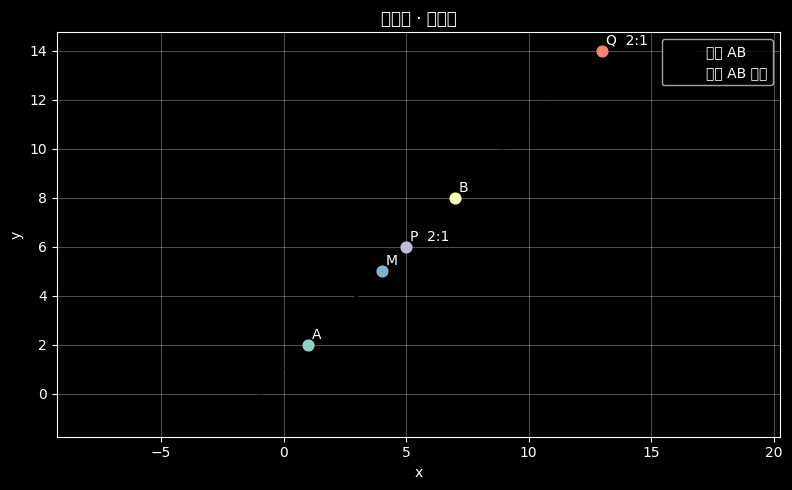

In [4]:
plt.figure(figsize=(8, 5))
# 선분 AB (내분 구간)
plt.plot([A[0], B[0]], [A[1], B[1]], 'k-', lw=2, label='선분 AB')
# 외분점을 보기 위해 직선 연장
t = np.linspace(-0.5, 1.8, 50)
line = A[None, :] + t[:, None] * (B - A)
plt.plot(line[:, 0], line[:, 1], 'k--', alpha=0.35, label='직선 AB 연장')

for pt, name, c in [(A, 'A', 'C0'), (B, 'B', 'C1'),
                    (P, f'P  {m}:{n}', 'C2'),
                    (Q, f'Q  {m}:{n}', 'C3'),
                    (M, 'M', 'C4')]:
    plt.scatter(*pt, color=c, s=60, zorder=5)
    plt.annotate(name, xy=pt, xytext=(pt[0]+0.15, pt[1]+0.25))

plt.xlabel('x'); plt.ylabel('y')
plt.title('내분점 · 외분점')
plt.legend(loc='best'); plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.tight_layout(); plt.show()
